## OANDO STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

oando=pd.read_csv('../stock_data/oando.csv') ## so it can be small letter. This is cool.
oando=oando.drop(columns=['high_price','low_price'])
oando.rename(columns={'trade_date':'date'},inplace=True)
oando['date']=pd.to_datetime(oando['date'])
oando['month']=oando['date'].dt.month
oando['quarter']=oando['date'].dt.quarter
oando['year']=oando['date'].dt.year

oando

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42849,OANDO,2017-01-03,4.47,4.47,1452695,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43409,OANDO,2017-01-04,4.30,4.30,3681006,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43519,OANDO,2017-01-05,4.54,4.54,3435874,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43629,OANDO,2017-01-06,4.69,4.69,51133231,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43719,OANDO,2017-01-09,4.55,4.55,6142518,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298113,OANDO,2026-07-13,39.00,39.00,4642818,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298551,OANDO,2026-07-14,38.00,38.00,6820385,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298989,OANDO,2026-07-15,38.00,38.00,4772912,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299427,OANDO,2026-07-16,39.00,39.00,3108220,2026-07-16T15:10:03.113936+00:00,7,3,2026


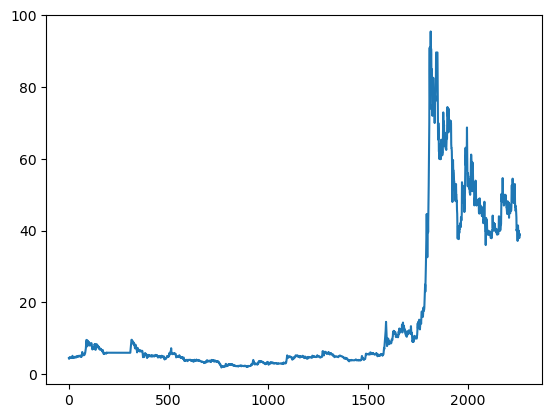

In [2]:
import matplotlib.pyplot as plt

plt.plot(oando['close_price'])
plt.show()

In [3]:
oando_end_month_df = (
    oando
    .sort_values("date")
    .groupby(oando["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

oando_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45419,OANDO,2017-01-31,4.66,4.66,2096600,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47242,OANDO,2017-02-28,4.90,4.90,3240048,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49358,OANDO,2017-03-31,5.00,5.00,1730565,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51185,OANDO,2017-04-28,5.78,5.78,5393654,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53108,OANDO,2017-05-31,8.45,8.45,6674929,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35350,OANDO,2026-03-31,50.00,50.00,6570838,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281176,OANDO,2026-04-30,46.00,46.00,3964252,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284242,OANDO,2026-05-29,51.00,51.00,5886079,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294170,OANDO,2026-06-30,39.95,39.95,4224935,2026-06-30T15:10:03.08168+00:00,6,2,2026


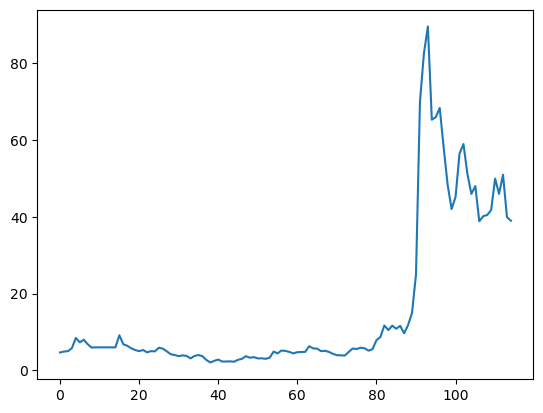

In [4]:
plt.plot(oando_end_month_df['close_price'])
plt.show()

In [5]:
oando_end_month_df['returns']=oando_end_month_df['close_price'].pct_change()*100
oando_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45419,OANDO,2017-01-31,4.66,4.66,2096600,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47242,OANDO,2017-02-28,4.90,4.90,3240048,2026-04-08T02:44:45.006295+00:00,2,1,2017,5.150215
2,49358,OANDO,2017-03-31,5.00,5.00,1730565,2026-04-08T02:45:42.281198+00:00,3,1,2017,2.040816
3,51185,OANDO,2017-04-28,5.78,5.78,5393654,2026-04-08T02:51:55.619599+00:00,4,2,2017,15.600000
4,53108,OANDO,2017-05-31,8.45,8.45,6674929,2026-04-08T02:52:57.421655+00:00,5,2,2017,46.193772
...,...,...,...,...,...,...,...,...,...,...,...
110,35350,OANDO,2026-03-31,50.00,50.00,6570838,2026-03-31T15:00:02.085058+00:00,3,1,2026,19.617225
111,281176,OANDO,2026-04-30,46.00,46.00,3964252,2026-04-30T15:00:02.170664+00:00,4,2,2026,-8.000000
112,284242,OANDO,2026-05-29,51.00,51.00,5886079,2026-05-29T15:00:02.455558+00:00,5,2,2026,10.869565
113,294170,OANDO,2026-06-30,39.95,39.95,4224935,2026-06-30T15:10:03.08168+00:00,6,2,2026,-21.666667


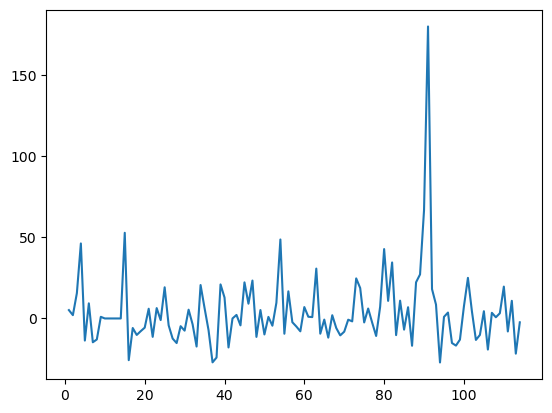

In [6]:
plt.plot(oando_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(oando_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(-8.206662219086203, 6.994962747200718e-13, 0, 113, {'1%': -3.489589552580676, '5%': -2.887477210140433, '10%': -2.580604145195395}, 919.3658052652964)
stationary


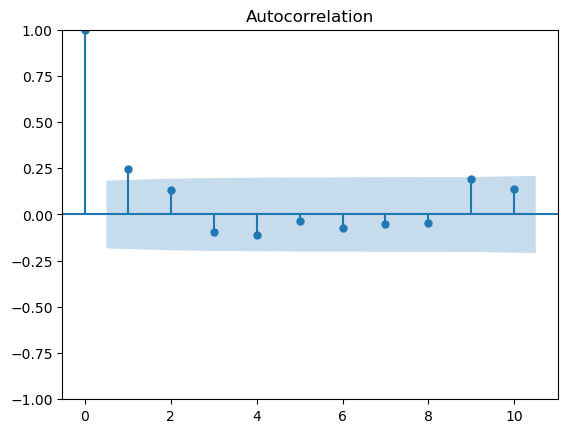

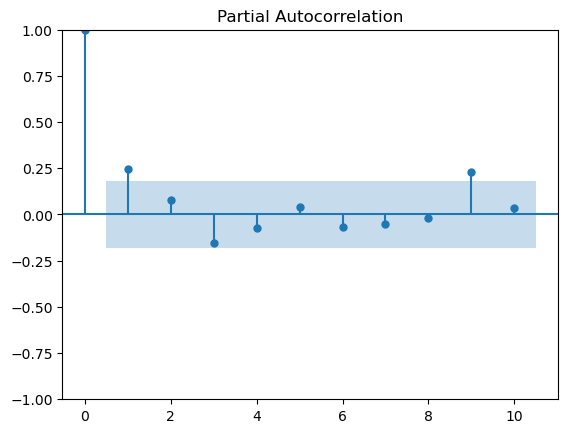

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(oando_end_month_df['returns'].dropna(), lags=10)
plot_pacf(oando_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=oando_end_month_df['close_price'][:-10]
test=oando_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -93.5047182901425]
[0, 0, 0, 0, 0, 1, -7.295595259522587]
[0, 0, 0, 0, 0, 2, -8.982426744097623]
[0, 0, 0, 0, 1, 0, -23.010380114975575]
[0, 0, 0, 0, 1, 1, -21.647281160204226]
[0, 0, 0, 0, 1, 2, -21.707088093555726]
[0, 0, 0, 0, 2, 0, -237.45016101756636]
[0, 0, 0, 0, 2, 1, -93.29552198080674]
[0, 0, 0, 0, 2, 2, -77.82131568664802]
[0, 0, 0, 1, 0, 0, -5.548079801210939]
[0, 0, 0, 1, 0, 1, -7.291045004408986]
[0, 0, 0, 1, 0, 2, -6.66178757073768]
[0, 0, 0, 1, 1, 0, -21.67975090352886]
[0, 0, 0, 1, 1, 1, -24.27950272260087]
[0, 0, 0, 1, 1, 2, -21.627160822794266]
[0, 0, 0, 1, 2, 0, -105.46891964829564]
[0, 0, 0, 1, 2, 1, -77.49234868455997]
[0, 0, 0, 1, 2, 2, -73.40101775474112]
[0, 0, 0, 2, 0, 0, -6.714903416746831]
[0, 0, 0, 2, 0, 1, -7.234137913492059]
[0, 0, 0, 2, 0, 2, -6.796043846672238]
[0, 0, 0, 2, 1, 0, -21.430137759836683]
[0, 0, 0, 2, 1, 1, -21.267517289404402]
[0, 0, 0, 2, 1, 2, -23.212327667803937]
[0, 0, 0, 2, 2, 0, -74.09818480421836]
[0, 0, 0, 2, 2, 1,

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
411,1,2,0,0,2,0,-6917.875341
654,2,2,0,0,2,0,-5853.839289
708,2,2,2,0,2,0,-3356.035316
195,0,2,1,0,2,0,-3245.451605
420,1,2,0,1,2,0,-2602.125473
...,...,...,...,...,...,...,...
263,1,0,0,2,0,2,-0.006299
351,1,1,1,0,0,0,0.001313
262,1,0,0,2,0,1,0.002409
254,1,0,0,1,0,2,0.005212


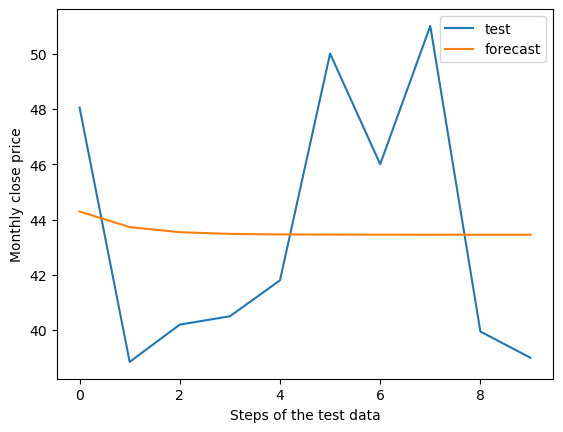

r2_score:  0.01761504948569359
rmse:  4.462339780213234
description:  count    115.000000
mean      15.631652
std       20.703554
min        2.050000
25%        4.250000
50%        5.670000
75%       11.625000
max       89.650000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=oando_end_month_df['close_price'][:-10]
y_test=oando_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,1,0), 
seasonal_order=(0,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', oando_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=oando_end_month_df['returns'].dropna()[:-10]
test=oando_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.0053847372827406925]
[0, 0, 0, 0, 0, 1, 0.00869168831416045]
[0, 0, 0, 0, 0, 2, 0.06276932428768278]
[0, 0, 0, 0, 1, 0, -1.7784888190442416]
[0, 0, 0, 0, 1, 1, -0.42174237453902497]
[0, 0, 0, 0, 1, 2, -0.9338951253535677]
[0, 0, 0, 0, 2, 0, -9.132212241657937]
[0, 0, 0, 0, 2, 1, -2.4257115267781058]
[0, 0, 0, 0, 2, 2, -1.6781778795486906]
[0, 0, 0, 1, 0, 0, 0.003942411869330087]
[0, 0, 0, 1, 0, 1, 0.06797159118441032]
[0, 0, 0, 1, 0, 2, 0.07106052450587719]
[0, 0, 0, 1, 1, 0, -3.5140914760243867]
[0, 0, 0, 1, 1, 1, -0.8784607578991335]
[0, 0, 0, 1, 1, 2, -0.42060021058632113]
[0, 0, 0, 1, 2, 0, -7.909180459497092]
[0, 0, 0, 1, 2, 1, -4.737165287837866]
[0, 0, 0, 1, 2, 2, -2.0130327669569237]
[0, 0, 0, 2, 0, 0, 0.07043210279051393]
[0, 0, 0, 2, 0, 1, 0.07632617339873371]
[0, 0, 0, 2, 0, 2, 0.06340834685650154]
[0, 0, 0, 2, 1, 0, -1.03070747379323]
[0, 0, 0, 2, 1, 1, -0.4325738504280294]
[0, 0, 0, 2, 1, 2, -0.6486716341206671]
[0, 0, 0, 2, 2, 0, -7.881176407038337]


In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-34393.228830
169,0,2,0,0,2,1,-8981.867690
165,0,2,0,0,1,0,-6918.873193
177,0,2,0,1,2,0,-6134.876174
186,0,2,0,2,2,0,-3204.891615
...,...,...,...,...,...,...,...
290,1,0,1,2,0,2,0.124566
504,2,0,0,2,0,2,0.135642
531,2,0,1,2,0,2,0.140966
74,0,0,2,2,0,2,0.149651


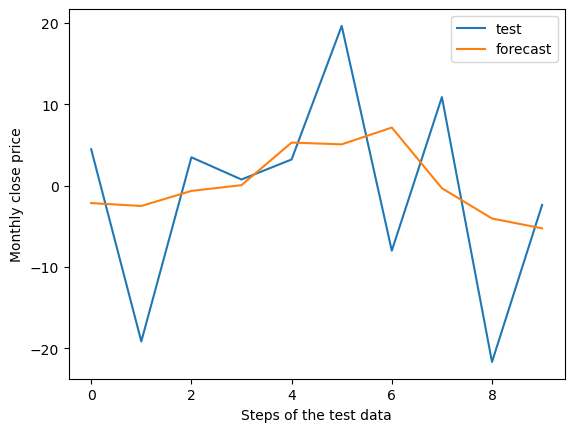

r2_score:  0.1500666383213871
rmse:  11.07722706438663
description:  count    114.000000
mean       3.763536
std       23.465058
min      -27.105410
25%       -9.058693
50%        0.000000
75%        8.951959
max      179.800000
Name: returns, dtype: float64


In [14]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=oando_end_month_df['returns'].dropna()[:-10]
y_test=oando_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,0,2), 
seasonal_order=(2,0,2,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', oando_end_month_df.returns.dropna().describe())

We will work with this
